https://github.com/jgehrcke/covid-19-germany-gae/blame/master/cases-rki-by-ags.csv

data saved in same folder as other survstat data

## dataprocessing

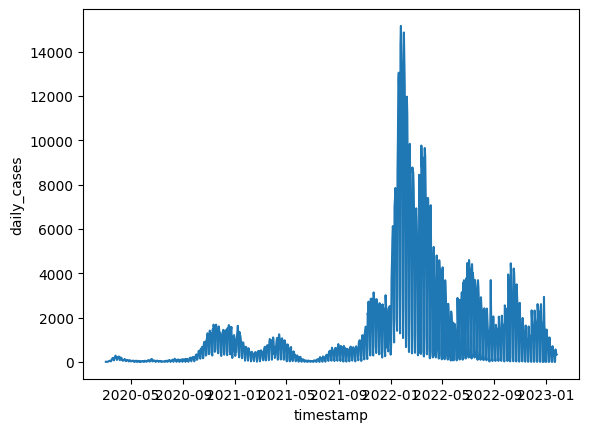

In [47]:
from src.utils import get_data_env
import os 
import pandas as pd
from itertools import product

raw_data = pd.read_csv(os.path.join(get_data_env(),'raw/cases-rki-by-ags.csv'))
raw_data['timestamp'] =  pd.to_datetime(raw_data['time_iso8601']).dt.date
raw_data.drop(columns = ['time_iso8601'], inplace = True)

raw_data_long           =  raw_data.melt(id_vars = 'timestamp', var_name='nuts3', value_name='cases')
raw_data_long['nuts3']  = raw_data_long['nuts3'].str.zfill(5)

# one error in nuts3: 16056 has become part of 16063
raw_data_long.loc[raw_data_long['nuts3'] == '16056', 'nuts3'] = '16063'

# Filter out unwanted nuts3 codes FIRST
filter_nuts = ['11001','11002','11003','11004','11005','11006','11007','11008','11009','11010','11011','11012','sum_cases']
raw_data_long = raw_data_long[~raw_data_long['nuts3'].isin(filter_nuts)]

# Group by timestamp and nuts3
raw_data_long = raw_data_long.groupby(['timestamp','nuts3'])['cases'].sum().reset_index(drop = False)

# NOW create complete index with only the remaining nuts3 codes
all_timestamps = raw_data_long['timestamp'].unique()
all_nuts3 = raw_data_long['nuts3'].unique()

complete_index = pd.DataFrame(
    list(product(all_timestamps, all_nuts3)),
    columns=['timestamp', 'nuts3']
)

# Merge to find missing combinations and fill with 0
raw_data_long = complete_index.merge(
    raw_data_long, 
    on=['timestamp', 'nuts3'], 
    how='left'
)
raw_data_long['cases'] = raw_data_long['cases'].fillna(0)

# Continue with processing
df = raw_data_long.sort_values(['nuts3', 'timestamp'])

df['daily_cases'] = df.groupby('nuts3')['cases'].diff()
df.loc[df['daily_cases'] < 0, 'daily_cases'] = 0
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.lineplot(df[df['nuts3'] == '11000'], x = 'timestamp', y = 'daily_cases')

preprocessed_data = df[['timestamp','nuts3','daily_cases']].rename(columns = {'daily_cases':'cases','nuts3':'kz_kreis'})
iso = df['timestamp'].dt.isocalendar()

preprocessed_data['year'] = iso.year
preprocessed_data['week'] = iso.week
preprocessed_data['day'] = iso.day

preprocessed_data.loc[preprocessed_data['cases'].isna(), 'cases'] = 0
preprocessed_data.reset_index(drop = True, inplace=True)
preprocessed_data = preprocessed_data[['week','kz_kreis','cases','year','timestamp','day']]
preprocessed_data.to_csv(os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/covid_daily.csv'), index=False)

## dataloading

In [48]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    weekly_time_index   = False,
    daily_time_index    = True,
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23501062/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


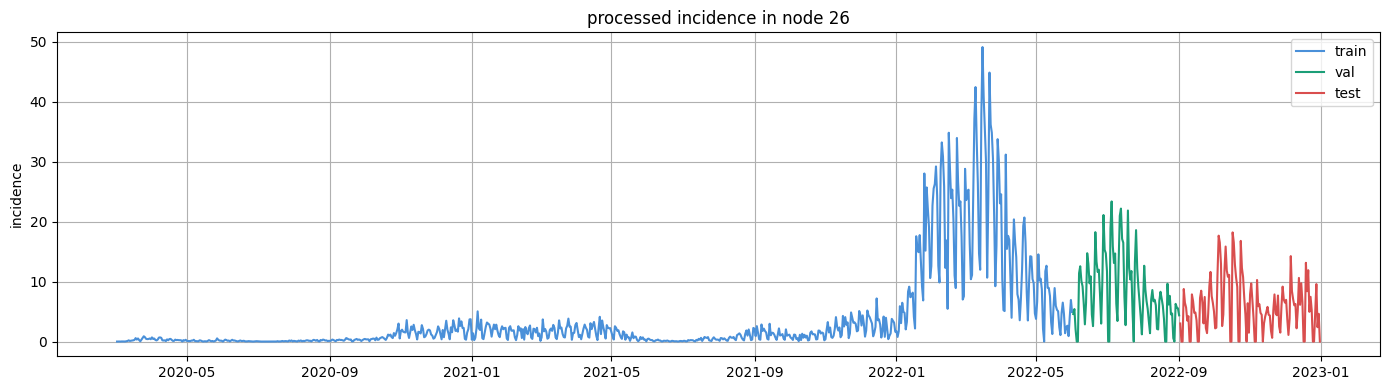

In [49]:
import pandas as pd
data_orchestrator.preview(26).show()

In [50]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

gl1 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
gl3 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))

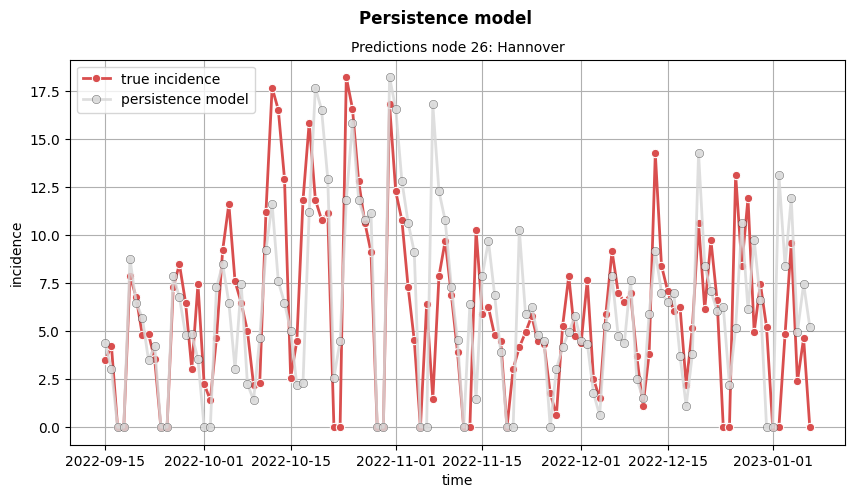

In [51]:
f1.show()

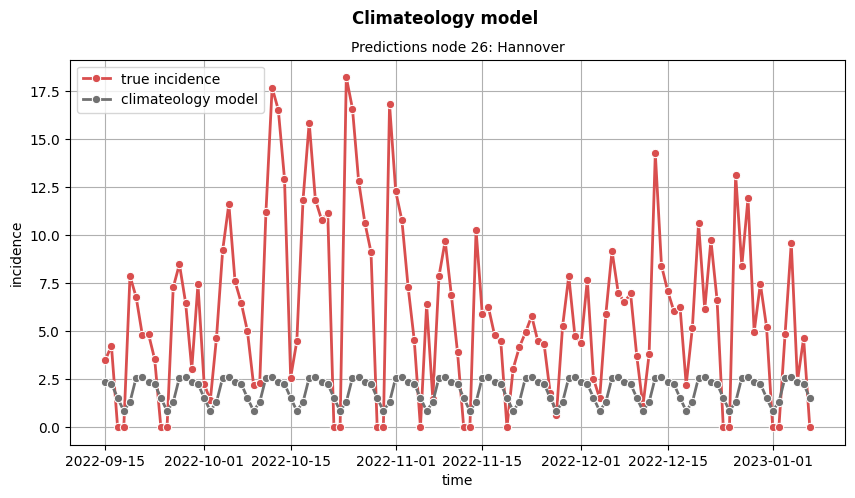

In [52]:
f2.show()


==                   nodelstm                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 1), y=(400, 1))
Epoch 001 train loss: 0.6020, val loss: 0.4405 ✓ (new best)
Epoch 002 train loss: 0.2668, val loss: 0.3937 ✓ (new best)
Epoch 003 train loss: 0.2396, val loss: 0.3744 ✓ (new best)
Epoch 004 train loss: 0.2231, val loss: 0.3688 ✓ (new best)
Epoch 005 train loss: 0.2135, val loss: 0.3696 (patience: 1/10)
Epoch 006 train loss: 0.2070, val loss: 0.3718 (patience: 2/10)
Epoch 007 train loss: 0.2032, val loss: 0.3737 (patience: 3/10)
Epoch 008 train loss: 0.2007, val loss: 0.3749 (patience: 4/10)
Epoch 009 train loss: 0.1989, val loss: 0.3756 (patience: 5/10)
Epoch 010 train loss: 0.1974, val loss: 0.3755 (patience: 6/10)
Epoch 011 train loss: 0.1965, val loss: 0.3749 (patience: 7/10)
lr has been updated from 1.00e-05 to 5.00e-06
Epoch 012 train loss: 0.2028, val loss: 0.3553 ✓ (new best)
Epoch 013 train loss: 0.1985, val loss: 0.3547 ✓ (new be

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 466.86it/s]


Test loss: 0.2682
forecasted ✓


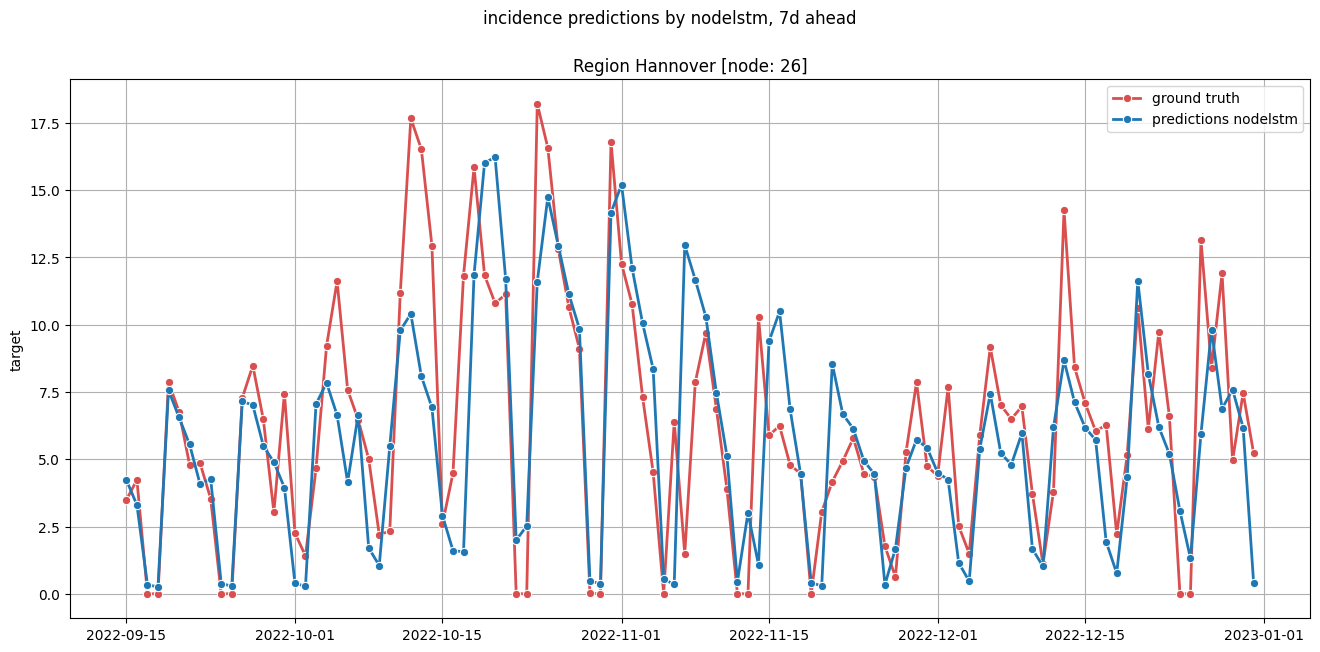

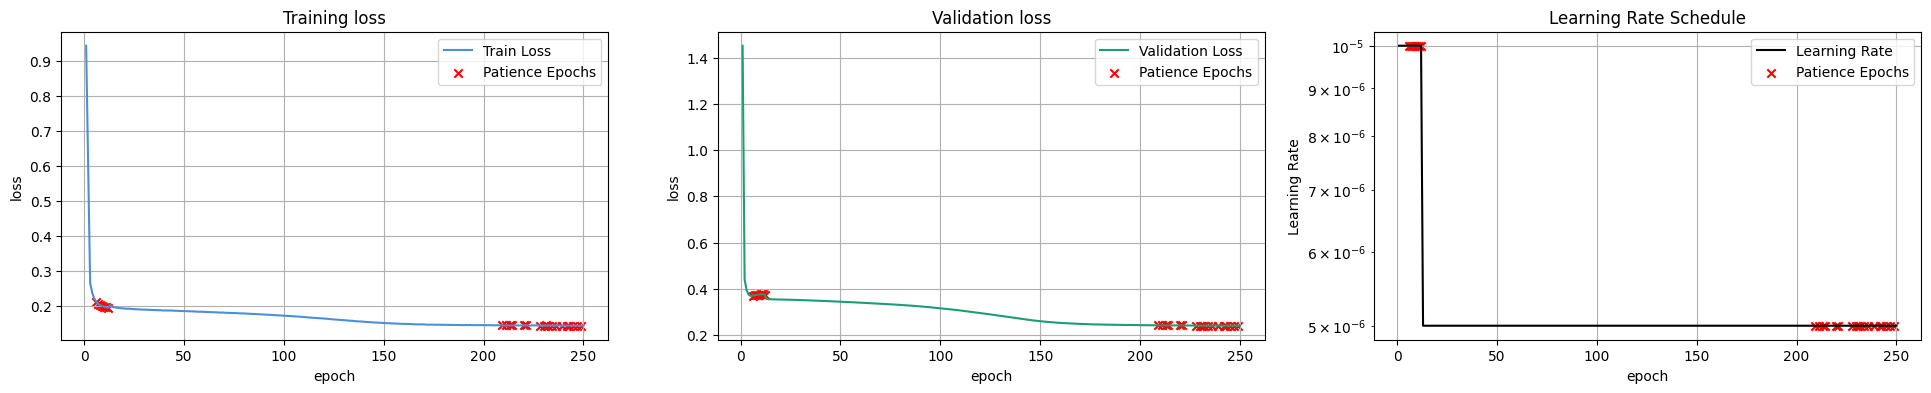

In [53]:
from src.models import NodeLSTMModel

lr = 0.00001

n_epochs= 250
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

lstm = NodeLSTMModel(dl, verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26).show()


==              gcn_identity_graph              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9752, val loss: 1.2792 ✓ (new best)
Epoch 002 train loss: 0.9134, val loss: 1.2029 ✓ (new best)
Epoch 003 train loss: 0.8329, val loss: 1.1068 ✓ (new best)
Epoch 004 train loss: 0.7354, val loss: 0.9909 ✓ (new best)
Epoch 005 train loss: 0.6277, val loss: 0.8589 ✓ (new best)
Epoch 006 train loss: 0.5198, val loss: 0.7180 ✓ (new best)
Epoch 007 train loss: 0.4232, val loss: 0.5827 ✓ (new best)
Epoch 008 train loss: 0.3457, val loss: 0.4657 ✓ (new best)
Epoch 009 train loss: 0.2888, val loss: 0.3746 ✓ (new best)
Epoch 010 train loss: 0.2514, val loss: 0.3132 ✓ (new best)
Epoch 011 train loss: 0.2288, val loss: 0.2788 ✓ (new best)
Epoch 012 train loss: 0.2175, val loss: 0.2626 ✓ (new best)
Epoch 013 train loss: 0.2109, val loss: 0.2560 ✓ (new best)
Epoch 014 train loss: 0.2072

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2421
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 625.38it/s]


Test loss: 0.2730
forecasted ✓

==              gcn_geo_neighbors               ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.9444, val loss: 1.5927 ✓ (new best)
Epoch 002 train loss: 0.9040, val loss: 1.5334 ✓ (new best)
Epoch 003 train loss: 0.8514, val loss: 1.4600 ✓ (new best)
Epoch 004 train loss: 0.7861, val loss: 1.3694 ✓ (new best)
Epoch 005 train loss: 0.7117, val loss: 1.2622 ✓ (new best)
Epoch 006 train loss: 0.6336, val loss: 1.1428 ✓ (new best)
Epoch 007 train loss: 0.5586, val loss: 1.0156 ✓ (new best)
Epoch 008 train loss: 0.4889, val loss: 0.8853 ✓ (new best)
Epoch 009 train loss: 0.4254, val loss: 0.7574 ✓ (new best)
Epoch 010 train loss: 0.3696, val loss: 0.6431 ✓ (new best)
Epoch 011 train loss: 0.3229, val loss: 0.5483 ✓ (new best)
Epoch 012 train loss: 0.2857, val loss: 0.4762 ✓ (new best)
Epoch 013 train loss: 0.2593, val loss: 0.4269 ✓ (new b

...

Test loss: 0.3184
forecasted ✓

==                 gcn_commuter                 ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9427, val loss: 1.4784 ✓ (new best)
Epoch 002 train loss: 0.9008, val loss: 1.4002 ✓ (new best)
Epoch 003 train loss: 0.8520, val loss: 1.3120 ✓ (new best)
Epoch 004 train loss: 0.7923, val loss: 1.2092 ✓ (new best)
Epoch 005 train loss: 0.7201, val loss: 1.0867 ✓ (new best)
Epoch 006 train loss: 0.6335, val loss: 0.9499 ✓ (new best)
Epoch 007 train loss: 0.5407, val loss: 0.7946 ✓ (new best)
Epoch 008 train loss: 0.4489, val loss: 0.6406 ✓ (new best)
Epoch 009 train loss: 0.3686, val loss: 0.5041 ✓ (new best)
Epoch 010 train loss: 0.3075, val loss: 0.3965 ✓ (new best)
Epoch 011 train loss: 0.2643, val loss: 0.3218 ✓ (new best)
Epoch 012 train loss: 0.2379, val loss: 0.2785 ✓ (new best)
Epoch 013 train loss: 0.2243, val loss: 0.2575 ✓ (new bes

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2413
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 626.75it/s]


Test loss: 0.2728
forecasted ✓


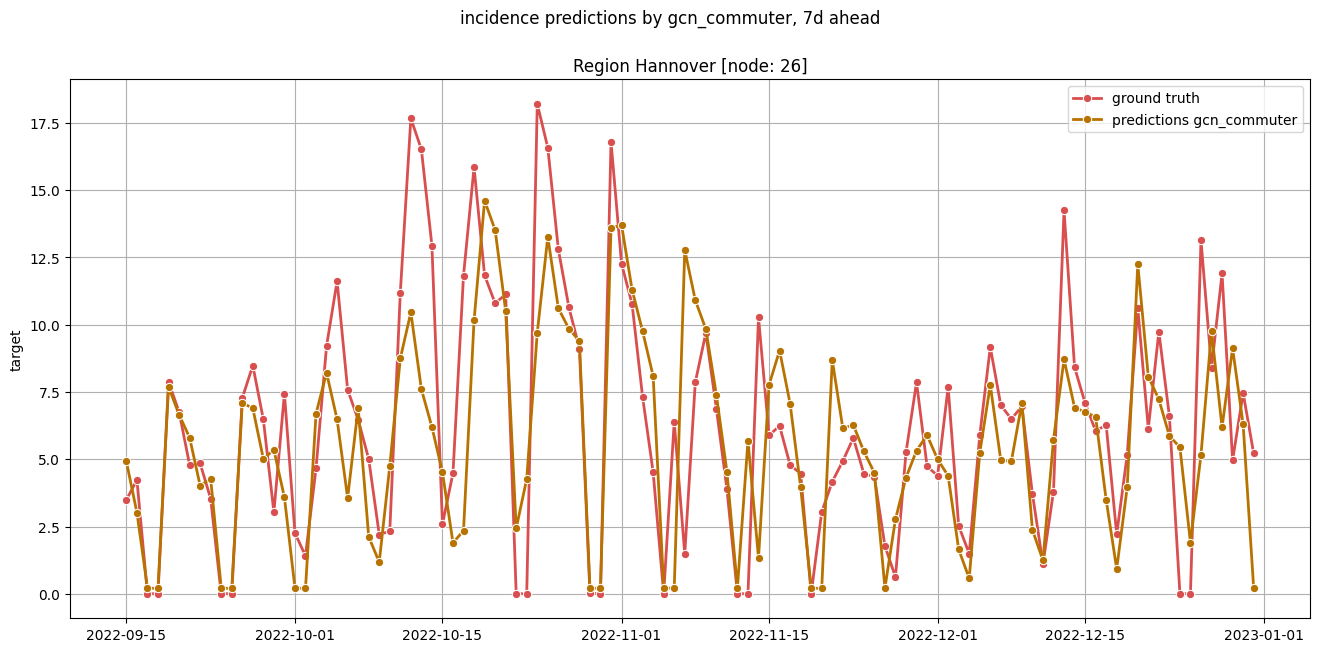

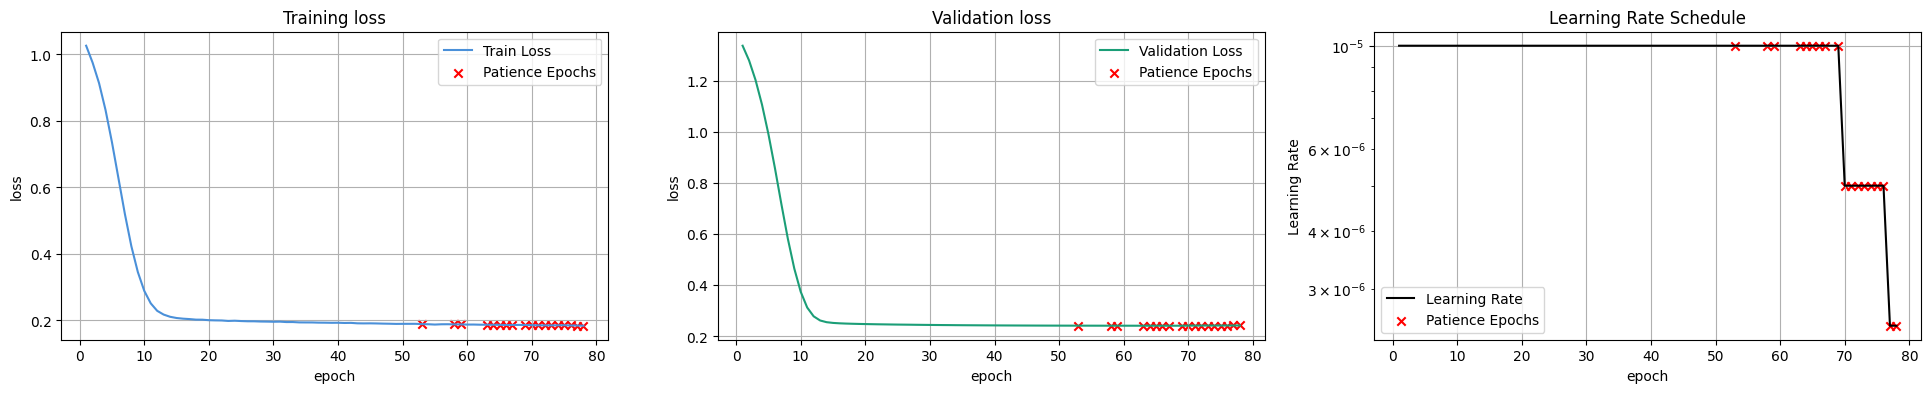

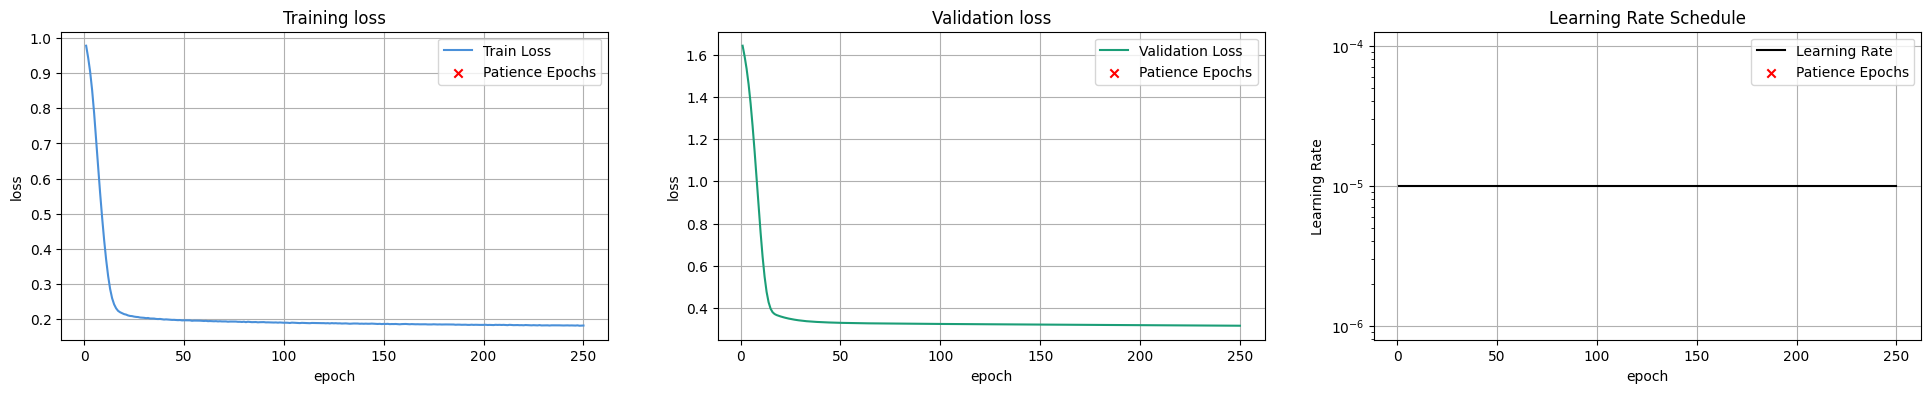

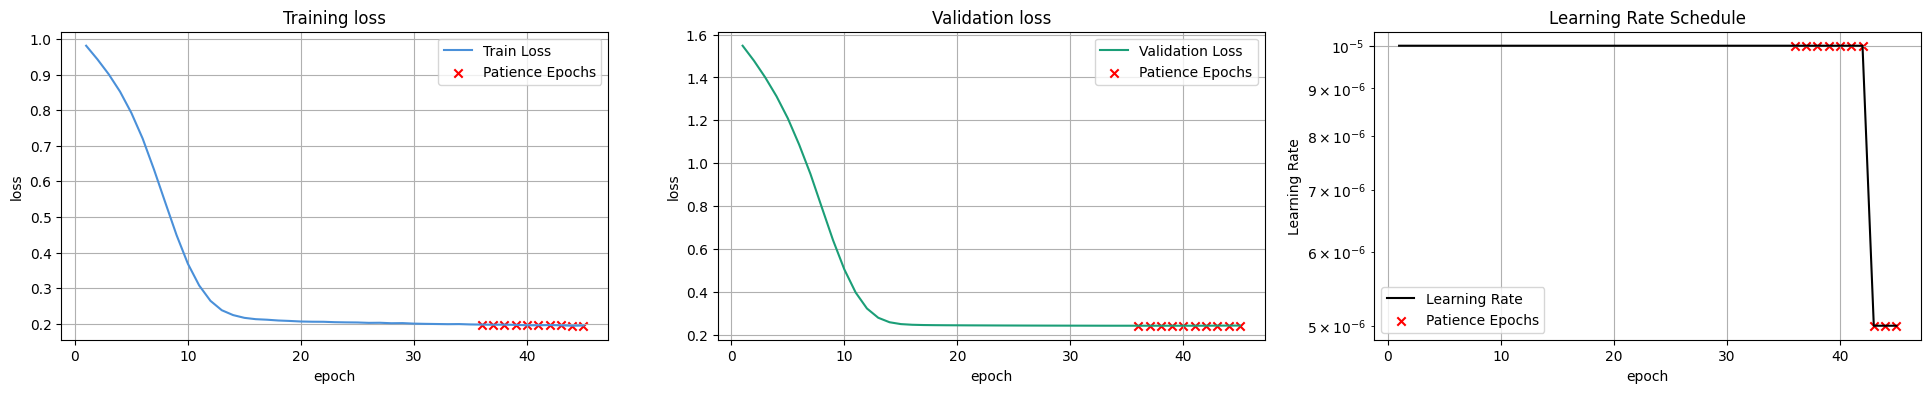

In [54]:
from src.models import SpatialGNNModel

lr = 0.00001

min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gcn1 = SpatialGNNModel(gl1, name='gcn_identity_graph', verbose = 2)
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26).show()

gcn2 = SpatialGNNModel(gl2, name='gcn_geo_neighbors', verbose = 2)
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
gcn2.show_forecasts(26).show()

gcn3 = SpatialGNNModel(gl1, name='gcn_commuter', verbose = 2)
gcn3.set_model_hparams()
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
gcn3.show_forecasts(26).show()


==             gatv2_identity_graph             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.3787, val loss: 0.8793 ✓ (new best)
Epoch 002 train loss: 0.2957, val loss: 0.7653 ✓ (new best)
Epoch 003 train loss: 0.2686, val loss: 0.6232 ✓ (new best)
Epoch 004 train loss: 0.2480, val loss: 0.5086 ✓ (new best)
Epoch 005 train loss: 0.2318, val loss: 0.4365 ✓ (new best)
Epoch 006 train loss: 0.2213, val loss: 0.3954 ✓ (new best)
Epoch 007 train loss: 0.2125, val loss: 0.3708 ✓ (new best)
Epoch 008 train loss: 0.2054, val loss: 0.3541 ✓ (new best)
Epoch 009 train loss: 0.1992, val loss: 0.3420 ✓ (new best)
Epoch 010 train loss: 0.1958, val loss: 0.3313 ✓ (new best)
Epoch 011 train loss: 0.1913, val loss: 0.3226 ✓ (new best)
Epoch 012 train loss: 0.1896, val loss: 0.3169 ✓ (new best)
Epoch 013 train loss: 0.1869, val loss: 0.3105 ✓ (new best)
Epoch 014 train loss: 0.1855

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2324
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 462.39it/s]


Test loss: 0.2710
forecasted ✓

==             gatv2_geo_neighbors              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.3472, val loss: 0.8655 ✓ (new best)
Epoch 002 train loss: 0.2708, val loss: 0.7962 ✓ (new best)
Epoch 003 train loss: 0.2451, val loss: 0.6817 ✓ (new best)
Epoch 004 train loss: 0.2294, val loss: 0.5851 ✓ (new best)
Epoch 005 train loss: 0.2196, val loss: 0.5245 ✓ (new best)
Epoch 006 train loss: 0.2131, val loss: 0.4912 ✓ (new best)
Epoch 007 train loss: 0.2067, val loss: 0.4700 ✓ (new best)
Epoch 008 train loss: 0.2020, val loss: 0.4566 ✓ (new best)
Epoch 009 train loss: 0.1979, val loss: 0.4456 ✓ (new best)
Epoch 010 train loss: 0.1948, val loss: 0.4364 ✓ (new best)
Epoch 011 train loss: 0.1930, val loss: 0.4281 ✓ (new best)
Epoch 012 train loss: 0.1905, val loss: 0.4195 ✓ (new best)
Epoch 013 train loss: 0.1883, val loss: 0.4117 ✓ (new b

...

Test loss: 0.2961
forecasted ✓

==                gatv2_commuter                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.3750, val loss: 0.9203 ✓ (new best)
Epoch 002 train loss: 0.2816, val loss: 0.8791 ✓ (new best)
Epoch 003 train loss: 0.2552, val loss: 0.7681 ✓ (new best)
Epoch 004 train loss: 0.2353, val loss: 0.6512 ✓ (new best)
Epoch 005 train loss: 0.2253, val loss: 0.5726 ✓ (new best)
Epoch 006 train loss: 0.2179, val loss: 0.5293 ✓ (new best)
Epoch 007 train loss: 0.2115, val loss: 0.5054 ✓ (new best)
Epoch 008 train loss: 0.2057, val loss: 0.4913 ✓ (new best)
Epoch 009 train loss: 0.2009, val loss: 0.4800 ✓ (new best)
Epoch 010 train loss: 0.1977, val loss: 0.4709 ✓ (new best)
Epoch 011 train loss: 0.1949, val loss: 0.4628 ✓ (new best)
Epoch 012 train loss: 0.1922, val loss: 0.4525 ✓ (new best)
Epoch 013 train loss: 0.1915, val loss: 0.4456 ✓ (new b

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.3488
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 448.89it/s]


Test loss: 0.3330
forecasted ✓


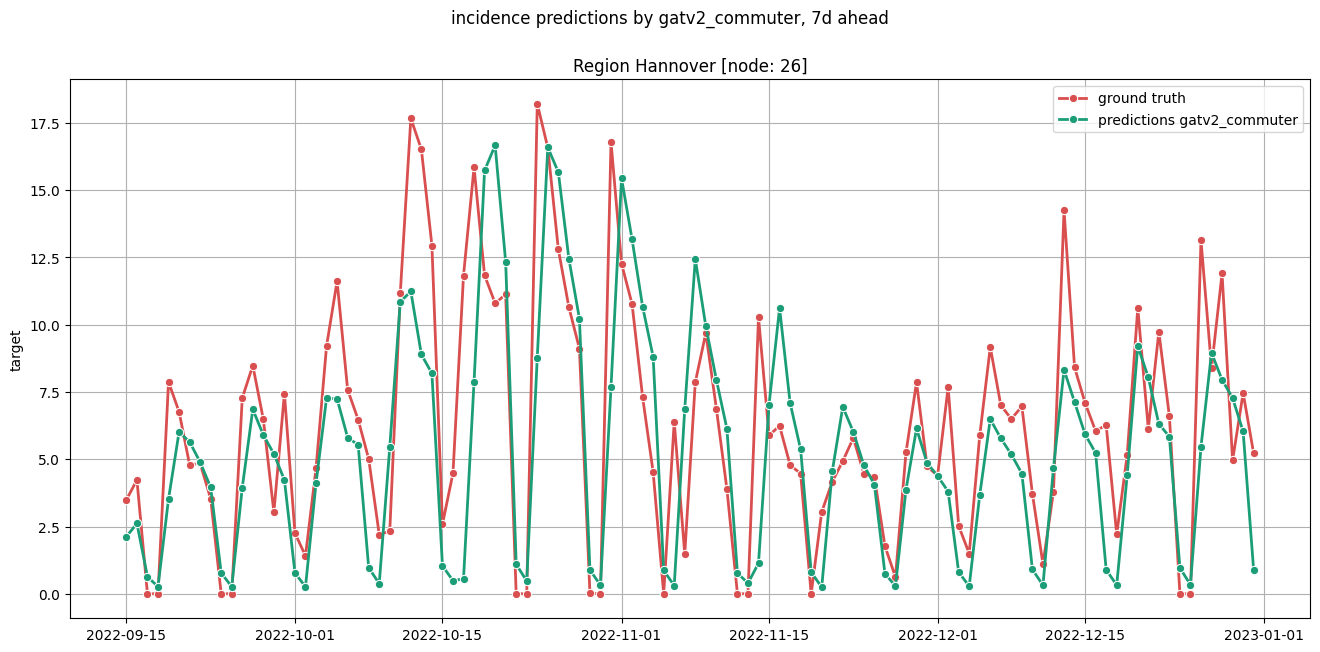

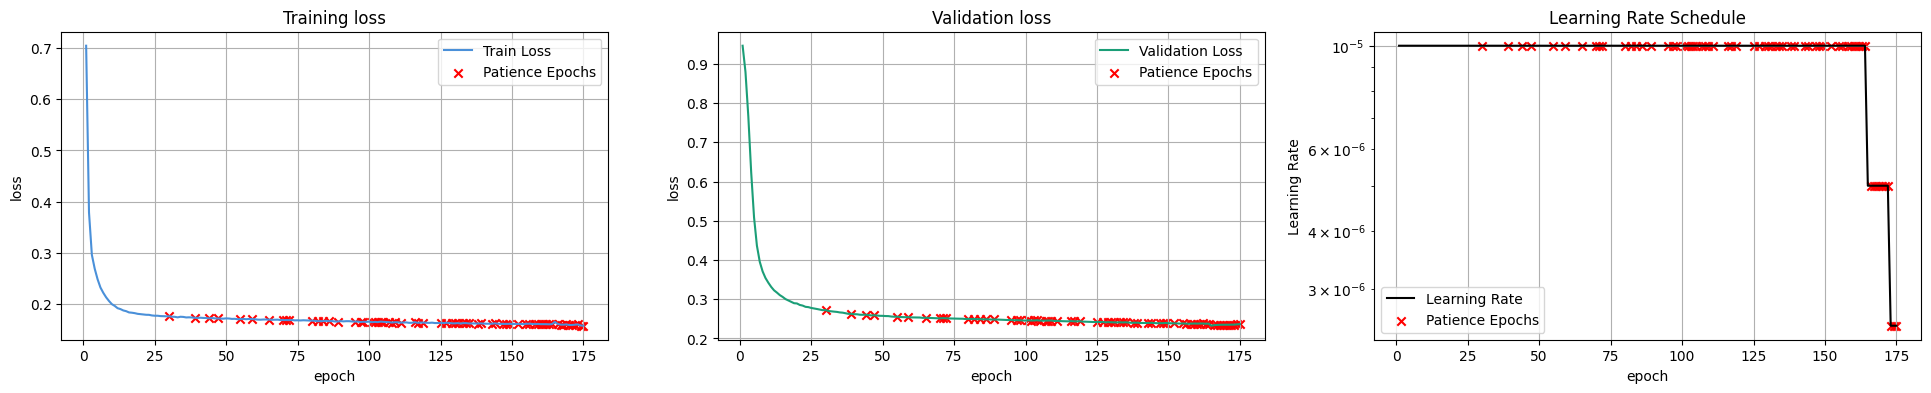

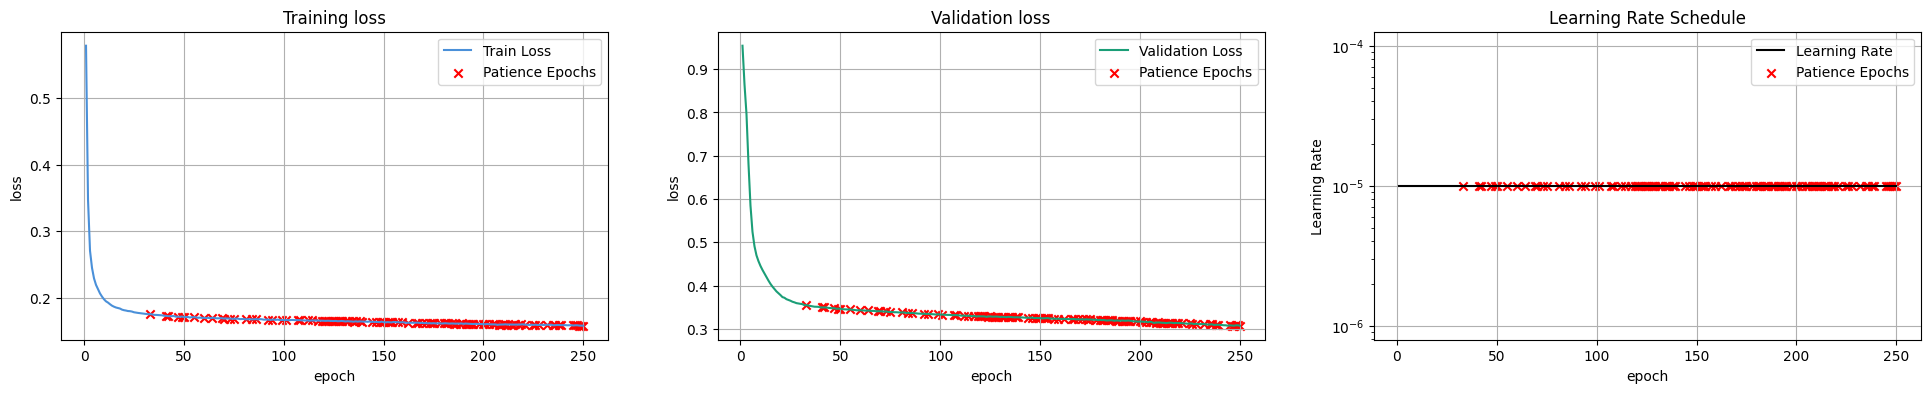

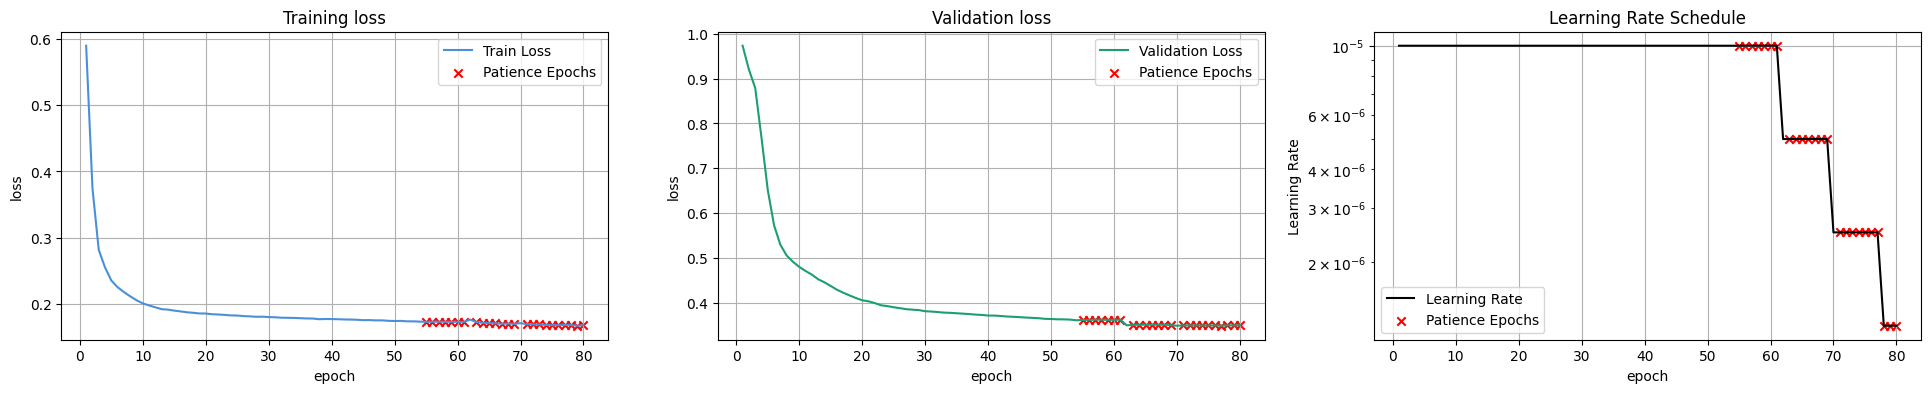

In [55]:
from src.models import GATv2Model

lr = 0.00001
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gat1 = GATv2Model(gl1, name='gatv2_identity_graph', verbose = 2)
gat1.set_model_hparams()
gat1.set_global_hparams(**global_hparams)
gat1.train()
gat1.forecast('test')
gat1.show_forecasts(26).show()

gat2 = GATv2Model(gl2, name='gatv2_geo_neighbors', verbose = 2)
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26).show()

gat3 = GATv2Model(gl3, name='gatv2_commuter', verbose = 2)
gat3.set_model_hparams()
gat3.set_global_hparams(**global_hparams)
gat3.train()
gat3.forecast('test')
gat3.show_forecasts(26).show()

In [56]:
predictioncollection = gat3.predictions.get_preds('test')
timesteps_ahead          = int(gat3.dataloadermanager.dataorchestrator.config.horizon_leadtime + 0)
evaluation_df = predictioncollection.get_original(0)

In [57]:
evaluation_df

evaluation_df['pred_moving'] = evaluation_df.groupby('node').rolling(7)['pred'].mean().reset_index(drop=True)
evaluation_df['target_moving'] = evaluation_df.groupby('node').rolling(7)['target'].mean().reset_index(drop=True)



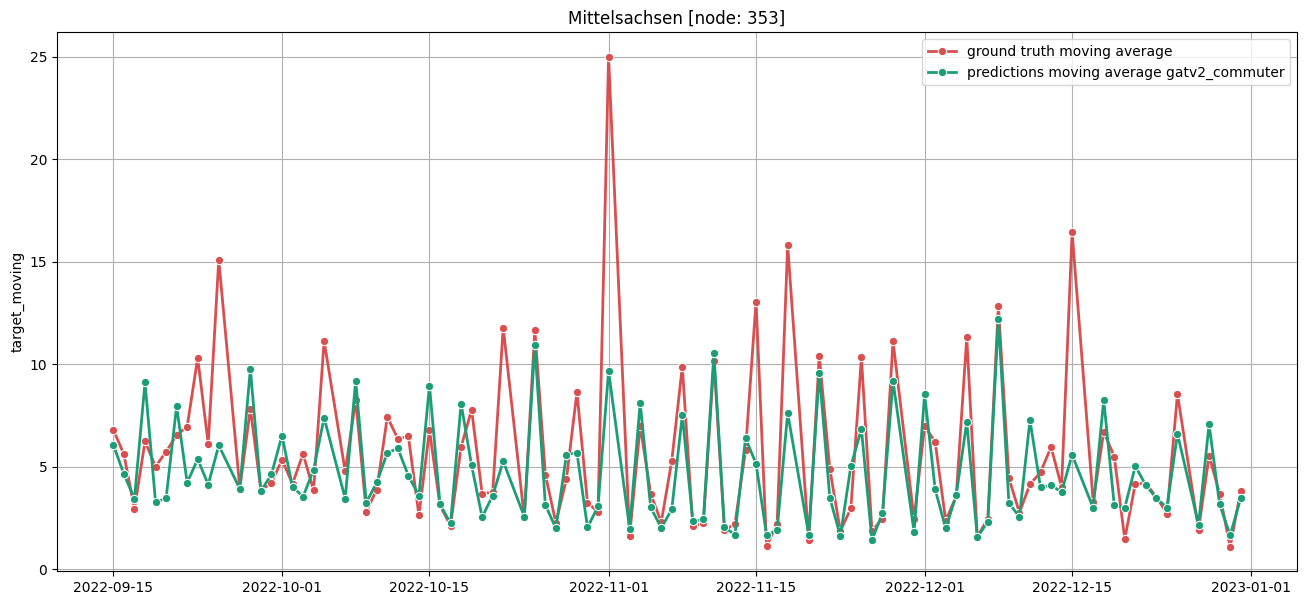

In [58]:
import matplotlib.pyplot as plt 
import seaborn as sns
from src.utils.colors import color_is_light, testcolor

node_idx = 353

moving_average = True



if isinstance(node_idx, int):
    node_idx = [node_idx]

n_plots     = len(node_idx)
fig, axes   = plt.subplots(n_plots ,1, figsize = (16, 2 + (5 * n_plots)))

if n_plots > 1:
    axes        = axes.flatten()           
else:
    axes = [axes]

for counter, id in enumerate(node_idx):
    ax = axes[counter]
    nutscode = gat3.tokenization_map['idx_id'][id]
    nodename = gat3.nutsnames[gat3.nutsnames[f'{gat3.nutslevel}_key'] == nutscode][f'{gat3.nutslevel}_name'].iloc[0]

    evaluation_df_node  = evaluation_df[evaluation_df['node'] == id]
    if moving_average:
        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target_moving',    color = testcolor,          marker = 'o',   label = 'ground truth moving average', ax = ax, linewidth = 2)

    else:
        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target',    color = testcolor,          marker = 'o',   label = 'ground truth', ax = ax, linewidth = 2)

    # if the luminence of the color is too high for a white background we give a black outline of line and marker
    if color_is_light(gat3.model_color):                  
        if moving_average:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)        
        else:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)
        
    else:
        if moving_average:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2)        
        else:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2)
    ax.set_title(f'{nodename} [node: {id}]')
    ax.set_xlabel("")            
    ax.grid()   

In [59]:
evaluation_df_node[['pred_moving','target_moving']].corr()

,pred_moving,target_moving
pred_moving,1.000000,0.726098
target_moving,0.726098,1.000000


In [60]:
from src.evaluation.metrics import RegressionMetrics

normal_metrics = RegressionMetrics(target_col = 'target', pred_col = 'pred')
print(f'ccc predictions {normal_metrics.ccc(evaluation_df_node)}')
rolling_average_metrics = RegressionMetrics(target_col = 'target_moving', pred_col = 'pred_moving')
print(f'ccc moving average predictions {rolling_average_metrics.ccc(evaluation_df_node)}')

ccc predictions 0.7142579555511475
ccc moving average predictions 0.5873280213331739


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:08<00:00,  1.40s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

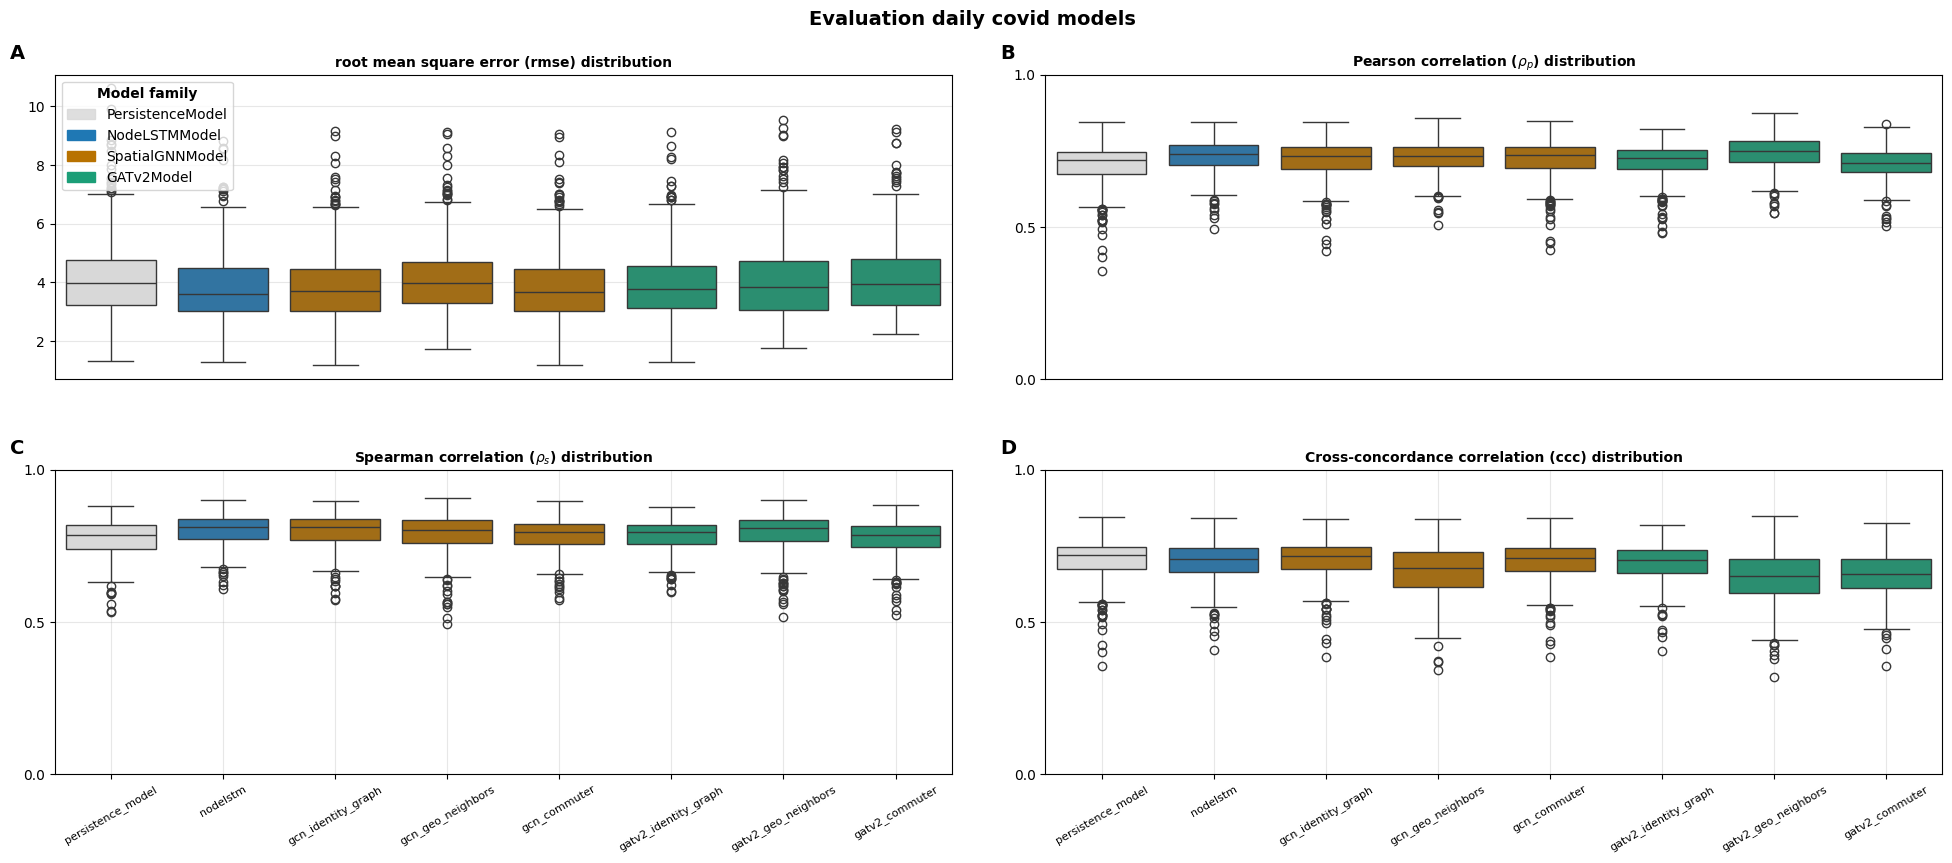

In [61]:
from src.evaluation import Evaluator

e = Evaluator([ps, lstm, gcn1,gcn2,gcn3, gat1, gat2, gat3]).add_evaluation()
raw_figure = e.plotter.plot_metric_compilation(plot_types = ['box','box','box','box'], metrics = ['rmse','pearson_corr','spearman_corr','ccc'])

f_evaluation = (raw_figure
    .labels.change_suptitle(suptitle='Evaluation daily covid models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 3)    
    .ticks.rotate_xticks(30)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)        
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)         
    )
f_evaluation.show()

In [62]:
metrics = e.metric_compilations.get_compilation('horizon_0','test')

In [63]:
for metric, metric_df in metrics.items():
    print("___________________")
    print(metric)
    for col in metric_df.columns.tolist():
        if col!='node':
            print(f'{col}: {metric_df[col].mean()}')

___________________
mse
persistence_model: 19.186355071375782
nodelstm: 16.373939466178417
gcn_identity_graph: 16.657607402801514
gcn_geo_neighbors: 18.610661624073984
gcn_commuter: 16.460679352283478
gatv2_identity_graph: 17.04978614270687
gatv2_geo_neighbors: 18.367408300042154
gatv2_commuter: 19.126120014190676
___________________
rmse
persistence_model: 4.156524135585141
nodelstm: 3.8537329159260976
gcn_identity_graph: 3.8851747566553057
gcn_geo_neighbors: 4.1422544887999555
gcn_commuter: 3.85855002674493
gatv2_identity_graph: 3.9429135117253757
gatv2_geo_neighbors: 4.054792398384104
gatv2_commuter: 4.18505958253531
___________________
pearson_corr
persistence_model: 0.7031082657571283
nodelstm: 0.7335023409873247
gcn_identity_graph: 0.7206401050090789
gcn_geo_neighbors: 0.7284202471375465
gcn_commuter: 0.7227757561206818
gatv2_identity_graph: 0.7141298928111791
gatv2_geo_neighbors: 0.744790503680706
gatv2_commuter: 0.707204967290163
___________________
spearman_corr
persistence_mo

In [64]:
metric_df

,node,persistence_model,nodelstm,gcn_identity_graph,gcn_geo_neighbors,gcn_commuter,gatv2_identity_graph,gatv2_geo_neighbors,gatv2_commuter
0,0,33.645190,45.836346,36.486702,38.562016,35.682564,37.152100,38.523235,40.454597
1,1,39.465880,38.144695,38.659321,45.895329,38.139423,37.604340,51.841026,44.929459
2,2,36.557744,37.893475,33.222797,42.040863,32.878922,40.195076,43.841736,46.275173
3,3,34.245041,37.930347,35.052608,27.631611,34.283543,39.006279,30.554146,34.989090
4,4,29.194544,35.332199,32.070789,26.979849,30.368620,35.504002,31.518021,32.733341
...,...,...,...,...,...,...,...,...,...
395,395,39.592214,42.235653,43.310432,47.667931,43.977486,43.798820,43.829872,47.654537
396,396,53.162450,56.843067,56.451618,62.362385,56.918907,52.317448,56.548553,56.299477
397,397,58.761174,54.892262,57.688850,55.044682,57.788574,55.137558,52.575630,56.138748
398,398,43.341861,42.272533,41.826500,52.658165,42.664627,39.005531,51.076038,49.379608


In [65]:
ccc['gatv2_commuter'].sort_values()

150    0.289536
60     0.331968
51     0.446896
141    0.481802
156    0.482007
         ...   
265    0.789316
5      0.796617
8      0.807338
260    0.823288
220    0.837360
Name: gatv2_commuter, Length: 400, dtype: float32

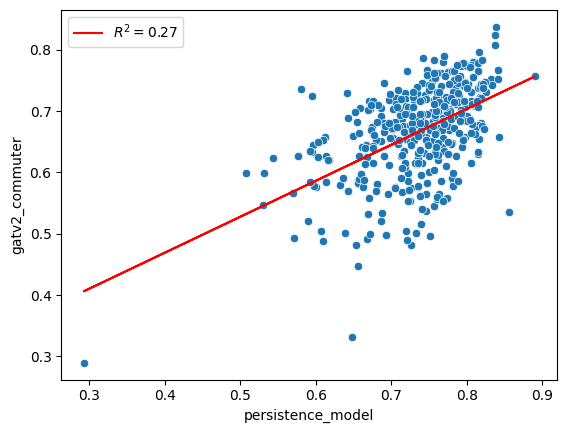

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

model2 = 'gatv2_commuter'
model1 = 'persistence_model'

# scatter plot
sns.scatterplot(data=ccc, x=model1, y=model2)

# fit linear regression
x = ccc[model1]
y = ccc[model2]
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# overlay regression line
plt.plot(x, intercept + slope*x, color='red', label=f'$R^2 = {r_value**2:.2f}$')

plt.legend()
plt.show()
